In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import pickle
from collections import Counter

import math
import matplotlib.pyplot as plt
import networkit as nk
import networkx as nx
import numpy as np
import pandas as pd
import scipy.stats as stats

from config import Config

In [3]:
# noinspection PyUnresolvedReferences
import main

In [15]:
def load_pkl_files(base_dir):
    data = {}
    for root, dirs, files in os.walk(base_dir):
        for file in files:
            if file.endswith(".pkl"):
                current_dir = os.path.basename(root)
                if current_dir != 'synthetic':
                    continue  # Skip files not in the 'synthetic' directory

                set_name = os.path.basename(os.path.dirname(root))
                file_path = os.path.join(root, file)
                print(file_path)

                with open(file_path, 'rb') as f:
                    pkl_content = pickle.load(f)

                if set_name in data:
                    print(f"Duplicate entry for {set_name}, skipping.")
                else:
                    data[set_name] = pkl_content
    return data


try:
    SCRIPT_DIR = os.path.dirname(os.path.realpath(__file__))
except NameError:
    SCRIPT_DIR = os.getcwd()

result_name = 'results_full_can_use'
base_directory = os.path.abspath(os.path.join(SCRIPT_DIR, '..', '..', 'data', 'output', result_name))
pkl_data = load_pkl_files(base_directory)

sorted_keys = sorted(pkl_data.keys(), key=lambda x: int(x))
G_list = []  # will hold *all* graphs from all sets
name = []  # will parallel G_list, storing the set name for each graph

# For each set, we ensure we have exactly 100 Graph objects
for set_name in sorted_keys:
    sublist = pkl_data[set_name]
    n_sub = len(sublist)

    if n_sub > 100:
        sublist = sublist[:100]
    elif n_sub < 100:
        raise Exception(
            f"Set {set_name} has only {n_sub} items instead of 100."
        )

    # Now sublist should be exactly 100 Graphs
    G_list.extend(sublist)  # add them to the main list
    name.extend([set_name] * 100)  # label each one with the set name

print("Total graphs in G_list:", len(G_list))
print("Total labels in name:", len(name))

/Users/william/workspace/PyCharmProjects/NetworkSynth/data/output/results_full_can_use/023/synthetic/nw_no_300_err_0.132_synthetic_network_20250124_061952.pkl
/Users/william/workspace/PyCharmProjects/NetworkSynth/data/output/results_full_can_use/014/synthetic/nw_no_300_err_0.136_synthetic_network_20250124_014245.pkl
/Users/william/workspace/PyCharmProjects/NetworkSynth/data/output/results_full_can_use/008/synthetic/nw_no_300_err_0.133_synthetic_network_20250123_233928.pkl
/Users/william/workspace/PyCharmProjects/NetworkSynth/data/output/results_full_can_use/020/synthetic/nw_no_300_err_0.139_synthetic_network_20250124_060015.pkl
/Users/william/workspace/PyCharmProjects/NetworkSynth/data/output/results_full_can_use/011/synthetic/nw_no_300_err_0.136_synthetic_network_20250124_004312.pkl
/Users/william/workspace/PyCharmProjects/NetworkSynth/data/output/results_full_can_use/029/synthetic/nw_no_300_err_0.137_synthetic_network_20250124_090857.pkl
/Users/william/workspace/PyCharmProjects/Netwo

In [19]:
from tqdm import tqdm

In [28]:
max_dim = []
min_dim = []
dimension = []
holder_exp = []
widths = []
avg_frac = []
avg_closeness = []
avg_degree = []
avg_clustering = []
max_al = []
min_al = []
avg_eig = []


def wnfd_nk(G, Q, weight=True, draw=False, fdigi=0):
    ## Find radius
    N_list = []
    r_g_all_set = set()
    num_nodes_all = nx.number_of_nodes(G)
    G = nx.convert_node_labels_to_integers(G)
    if weight:
        G_nk = nk.nxadapter.nx2nk(G, weightAttr='weight')
    else:
        G_nk = nk.nxadapter.nx2nk(G)
    for node in tqdm(G.nodes(), total=num_nodes_all):
        grow = []
        grow_ori = nk.distance.Dijkstra(G_nk, node, storePaths=False).run().getDistances()
        for s in grow_ori:
            if 0 < s < 99999:
                grow.append(s)
        grow.sort()
        # upf = (1/pow(10,fdigi+1)*5)
        # grow = [round(d+upf,fdigi) for d in grow]
        if fdigi == 0:
            grow = [math.ceil(d) for d in grow]
        else:
            grow = [round(d, fdigi) for d in grow if round(d, fdigi) != 0]
        #         grow = grow[1:]
        num = Counter(grow)
        r_g_all_set.update(num.keys())
        N_list.append(num)

    r_g_all = np.array(sorted(list(r_g_all_set)))
    Nw_mat = np.ones((len(N_list), len(r_g_all)))  # Num_r matrix: column: node, row: radius

    for i, num in enumerate(N_list):
        for j, r in enumerate(r_g_all):
            Nw_mat[i, j] += sum(count for radius, count in num.items() if radius <= r)

    ## Distortion factor q: get Zq_mat
    diameter = r_g_all[-1]
    # print('diameter:',diameter)

    Zq_list = []

    for q in Q:
        Zq_mat = np.power(Nw_mat / Nw_mat[:, -1, None], q)
        Zq_list.append(np.sum(Zq_mat, axis=0))

    ## Get tau(slope)
    tau_list = []
    if draw == True:
        plt.figure(figsize=(7, 7))
        for idx, q in enumerate(Q):
            r_g_all_np = np.array(r_g_all)
            x = np.log(r_g_all_np / diameter)
            y = np.log(Zq_list[idx])
            q = format(q, '.0f')
            plt.plot(x, y, '*', label='q=' + str(q))
            #         # plt.plot(x,y,'*',label='q='+str(q))
            #         # plt.legend(fontsize=10)
            slope, intercept, _, _, _ = stats.linregress(x, y)
            #             plt.plot(x,intercept + slope*x,alpha=0.5)
            tau_list.append(slope)
            plt.xlabel('ln(r/d)')
            plt.ylabel('ln(sum function)')
    else:
        for idx, q in enumerate(Q):
            r_g_all_np = np.array(r_g_all)
            x = np.log(r_g_all_np / diameter)
            # print('x:',x)
            y = np.log(Zq_list[idx])
            slope, intercept, _, _, _ = stats.linregress(x, y)
            tau_list.append(slope)
    # print('tau_list:',tau_list)

    return tau_list


def nspectrum(tau_list, q_list, k, color):
    al_list = []
    fal_list = []
    for i in range(1, len(q_list)):
        al = (tau_list[i] - tau_list[i - 1]) / (q_list[i] - q_list[i - 1])
        al_list.append(al)
    for j in range(len(q_list) - 1):
        fal = q_list[j] * al_list[j] - tau_list[j]
        fal_list.append(fal)
    plt.plot(al_list, fal_list, label=name[k], linewidth=3, color=color)
    plt.xlabel('Lipschitz-Hölder exponent, 'r'$\alpha$')
    plt.ylabel('Multi-fractal spectrum, 'r'$f(\alpha)$')
    # plt.legend()
    # plt.savefig('/Users/xiongyex/Downloads'+'/Spec_{}.png'.format(k),bbox_inches = 'tight',dpi=600)
    alpha_0 = al_list[np.argmax(fal_list)]
    width = np.max(al_list) - np.min(al_list)
    print('Holder Exponent:', alpha_0)
    print('width:', width)
    holder_exp.append(alpha_0)
    widths.append(width)
    max_al.append(np.max(al_list))
    min_al.append(np.min(al_list))
    return alpha_0, width


def ndimension(tau_list, q_list, k, color):
    dim_list = []
    qd_list = []
    for i in range(len(q_list)):
        if q_list[i] != 0:
            dim = tau_list[i] / q_list[i]
            dim_list.append(dim)
            qd_list.append(q_list[i])

    plt.plot(qd_list, dim_list, label=name[k], linewidth=3, color=color)
    plt.xlabel('Distorting exponent, 'r'$q$')
    plt.ylabel('Generalized fractal dimension, 'r'$D(q)$')
    # plt.legend()
    print('Dim_max: ', np.max(dim_list))
    print('Dim_min: ', np.min(dim_list))
    print('Dim_max-min: ', np.max(dim_list) - np.min(dim_list))
    max_dim.append(np.max(dim_list))
    min_dim.append(np.min(dim_list))
    dimension.append(np.max(dim_list) - np.min(dim_list))
    return dim_list
    # plt.savefig('/Users/xiongyex/Downloads'+'/Spec_{}.png'.format(k),bbox_inches = 'tight',dpi=600)

In [ ]:
kX_index = '20kX'
root = SCRIPT_DIR

##################################################### Calculate Holder Exponent and Width #####################################################
weight_flag = 'False'
holder_exp = []
widths = []
Q = [q / 100 for q in range(-2000, 2001, 10)]
wei_ntauls_list = []
for i in range(len(G_list)):
    if weight_flag == 'True':
        ntau = wnfd_nk(G_list[i], Q, weight=True, draw=False, fdigi=1)  # Peiyu: weight=None
    else:
        ntau = wnfd_nk(G_list[i], Q, weight=False, draw=False)
    wei_ntauls_list.append(ntau)
np.save(root + f'/div_ntauls_{kX_index}_{weight_flag}.npy', wei_ntauls_list)

plt.rcParams.update({'font.size': 30})
plt.figure(figsize=(10, 10))

 61%|██████    | 382/625 [00:00<00:00, 3816.49it/s]

Holder Exponent: 1.9186208053011893
width: 0.007916015429002332
Holder Exponent: 1.9765525366165524
width: 0.0038876818722139994
Holder Exponent: 1.8713164534733284
width: 0.0017890063192993466
Holder Exponent: 1.8982335750360322
width: 0.0024264386977159713
Holder Exponent: 1.8495682661922497
width: 0.006538189161136243
Holder Exponent: 1.882561230199089
width: 0.00912702710081481
Holder Exponent: 1.7472366674331603
width: 0.00807266063222567
Holder Exponent: 1.8083375706517044
width: 0.003969075546305101
Holder Exponent: 1.9110620535003604
width: 0.004998963022195602
Holder Exponent: 1.9529500407757616
width: 0.0051567997086712225


IndexError: list index out of range

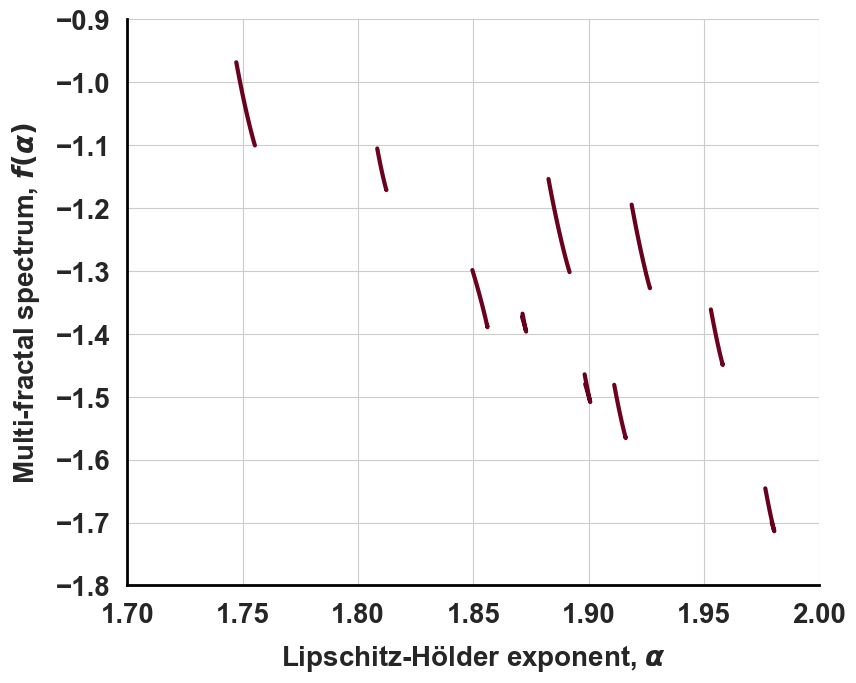

In [29]:
from matplotlib import rcParams, colormaps
from matplotlib.ticker import AutoMinorLocator

rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
rcParams['font.size'] = 20
rcParams['axes.linewidth'] = 2
rcParams['axes.labelpad'] = 10.0
# rcParams['axes.prop_cycle'] = plot_color_cycle
rcParams['axes.xmargin'] = 0
rcParams['axes.ymargin'] = 0
rcParams.update({"figure.figsize": (6.4, 4.8),
                 "figure.subplot.left": 0.177, "figure.subplot.right": 0.946,
                 "figure.subplot.bottom": 0.156, "figure.subplot.top": 0.965,
                 "axes.autolimit_mode": "round_numbers",
                 "xtick.major.size": 7,
                 "xtick.minor.size": 3.5,
                 "xtick.major.width": 1.1,
                 "xtick.minor.width": 1.1,
                 "xtick.major.pad": 5,
                 "xtick.minor.visible": True,
                 "ytick.major.size": 7,
                 "ytick.minor.size": 3.5,
                 "ytick.major.width": 1.1,
                 "ytick.minor.width": 1.1,
                 "ytick.major.pad": 5,
                 "ytick.minor.visible": True,
                 "lines.markersize": 10,
                 "lines.markerfacecolor": "none",
                 "lines.markeredgewidth": 0.8})

fig, ax = plt.subplots(figsize=(9, 7))
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
for spine in ax.spines.values():
    spine.set_edgecolor('black')

num_colors = len(wei_ntauls_list)
cmap = plt.get_cmap('RdBu')
colors = [cmap(i / (num_colors - 1)) for i in range(num_colors)]

for i in range(len(wei_ntauls_list)):
    # nspectrum(wei_ntauls_list[i],Q,i,color=colors[i])
    arg1 = wei_ntauls_list[i][:80]
    arg2 = Q[:80]
    nspectrum(arg1, arg2, i, color=colors[i])
print(holder_exp)
print(widths)

In [ ]:


y_min, y_max = ax.get_ylim()
ax.set_ylim(y_min, y_max + 0.1)
ax = plt.gca()
plt.gca().xaxis.set_minor_locator(AutoMinorLocator(n=2))
plt.gca().yaxis.set_minor_locator(AutoMinorLocator(n=2))
ax.legend(loc='upper right')
plt.grid(False)
# plt.legend(fontsize=25,loc='best')
# # plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
# plt.legend(frameon=False, prop={'size': 15}, loc='best')
# plt.grid(False)
# ax = plt.gca()
# ax.spines['right'].set_visible(False)
# ax.spines['top'].set_visible(False)
# for spine in ax.spines.values():
#     spine.set_linewidth(2)
#     spine.set_color('black')

plt.savefig(root + 'weighted_{}_nspectrum.svg'.format(kX_index), bbox_inches='tight', dpi=600)
plt.close()

##################################################### Calculate Dimension #####################################################
max_dim = []
min_dim = []
dimension = []
plt.rcParams.update({'font.size': 30})
plt.figure(figsize=(10, 10))
from matplotlib.ticker import AutoMinorLocator
from matplotlib import rcParams

rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
rcParams['font.size'] = 20
rcParams['axes.linewidth'] = 2
rcParams['axes.labelpad'] = 10.0
# rcParams['axes.prop_cycle'] = plot_color_cycle
rcParams['axes.xmargin'] = 0
rcParams['axes.ymargin'] = 0
rcParams.update({"figure.figsize": (6.4, 4.8),
                 "figure.subplot.left": 0.177, "figure.subplot.right": 0.946,
                 "figure.subplot.bottom": 0.156, "figure.subplot.top": 0.965,
                 "axes.autolimit_mode": "round_numbers",
                 "xtick.major.size": 7,
                 "xtick.minor.size": 3.5,
                 "xtick.major.width": 1.1,
                 "xtick.minor.width": 1.1,
                 "xtick.major.pad": 5,
                 "xtick.minor.visible": True,
                 "ytick.major.size": 7,
                 "ytick.minor.size": 3.5,
                 "ytick.major.width": 1.1,
                 "ytick.minor.width": 1.1,
                 "ytick.major.pad": 5,
                 "ytick.minor.visible": True,
                 "lines.markersize": 10,
                 "lines.markerfacecolor": "none",
                 "lines.markeredgewidth": 0.8})

fig, ax = plt.subplots(figsize=(9, 7))
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
for spine in ax.spines.values():
    spine.set_edgecolor('black')

Q = [q / 100 for q in range(-2000, 2001, 10)]
wei_ntauls_list = np.load(root + '/div_ntauls_{}_{}.npy'.format(kX_index, weight_flag), allow_pickle=True)
colors = ['#F14040', '#FF8000', '#37AD6B', '#B177DE']
for i in range(len(wei_ntauls_list)):
    print(name[i])
    ndimension(wei_ntauls_list[i], Q, i, color=colors[i])
print(dimension)

ax = plt.gca()
plt.gca().xaxis.set_minor_locator(AutoMinorLocator(n=2))
plt.gca().yaxis.set_minor_locator(AutoMinorLocator(n=2))
ax.legend(loc='upper right')
plt.grid(False)

# plt.legend(fontsize=25,loc='best')
# # plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
# plt.legend(frameon=False, prop={'size': 15}, loc='best')
# # plt.legend(ncol=10,frameon=False,prop={'size': 15}, loc='lower center', bbox_to_anchor=(0.5, -0.3))
# plt.grid(False)
# ax = plt.gca()
# ax.spines['right'].set_visible(False)
# ax.spines['top'].set_visible(False)
# for spine in ax.spines.values():
#     spine.set_linewidth(2)
#     spine.set_color('black')
plt.savefig(root + 'weighted_{}_ndimension.svg'.format(kX_index), bbox_inches='tight', dpi=600)

##################################################### Calculate NFD #####################################################
from tqdm import tqdm
from copy import deepcopy


def node_dimension(G, weight=True, fdigi=2):
    node_dimension = {}
    G = nx.convert_node_labels_to_integers(G)
    if weight:
        for u, v, d in G.edges(data=True):
            if d['weight'] != 0:
                d['weight'] = 1.0 / d['weight']
    if weight == None:
        G_nk = nk.nxadapter.nx2nk(G)
    else:
        G_nk = nk.nxadapter.nx2nk(G, weightAttr='weight')

    for node in G.nodes():
        grow = []
        r_g = []
        num_g = []
        num_nodes = 0
        grow = nk.distance.Dijkstra(G_nk, int(node), storePaths=False).run().getDistances()
        grow.sort()
        if weight == True:
            grow = [round(d, fdigi) for d in grow if round(d, fdigi) != 0]
        num = Counter(grow)
        for i, j in num.items():
            num_nodes += j
            if i > 0:
                r_g.append(i)
                num_g.append(num_nodes)

        x = np.log(r_g)
        y = np.log(num_g)

        if len(r_g) > 2:
            slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
            node_dimension[node] = slope
        else:
            node_dimension[node] = 0
    return node_dimension


nfd_centrality_list = []
avg_frac = []
for G in G_list:
    if weight_flag == 'True':
        nfd_centrality = node_dimension(G, weight=True).values()
    else:
        nfd_centrality = node_dimension(G, weight=None).values()  # Peiyu: weight=None
    nfd_centrality_list.append(list(nfd_centrality))
    avg_frac.append(np.mean(np.array(nfd_centrality_list[-1])))

# 将 nfd_centrality_list 转换为 DataFrame, violinplot 数据
df = pd.DataFrame(nfd_centrality_list).T
df.columns = name
df.to_csv(root + '/{}_nfd_violin.csv'.format(kX_index), index=False)

##################################################### Calculate Closeness centrality #####################################################
closeness_centrality_list = []
avg_closeness = []
for G in tqdm(G_list):
    if weight_flag == 'True':
        closeness_centrality = nx.closeness_centrality(G, distance=lambda u, v, d: 1 / d['weight']).values()
    else:
        closeness_centrality = nx.closeness_centrality(G, distance=None).values()
    closeness_centrality_list.append(list(closeness_centrality))
    avg_closeness.append(np.mean(np.array(closeness_centrality_list[-1])))

df = pd.DataFrame(closeness_centrality_list).T
df.columns = name
df.to_csv(root + '/{}_closeness_violin.csv'.format(kX_index), index=False)

##################################################### Calculate Degree centrality#####################################################
degree_centrality_list = []
avg_degree = []

for G in tqdm(G_list):
    if weight_flag == 'True':
        degree_centrality = dict(G.degree(weight='weight')).values()
    else:
        degree_centrality = dict(G.degree(weight=None)).values()
    degree_centrality_list.append(list(degree_centrality))
    avg_degree.append(np.mean(np.array(degree_centrality_list[-1])))

df = pd.DataFrame(degree_centrality_list).T
df.columns = name
df.to_csv(root + '/{}_degree_violin.csv'.format(kX_index), index=False)

##################################################### Calculate cluster_coef #####################################################
cluster_coef_list = []
avg_clustering = []

for G in tqdm(G_list):
    if weight_flag == 'True':
        cluster_coef = nx.clustering(G, weight='weight').values()
    else:
        cluster_coef = nx.clustering(G, weight=None).values()
    cluster_coef_list.append(list(cluster_coef))
    avg_clustering.append(np.mean(np.array(cluster_coef_list[-1])))
df = pd.DataFrame(cluster_coef_list).T
df.columns = name
df.to_csv(root + '/{}_clustering_violin.csv'.format(kX_index), index=False)

##################################################### Calculate betweenness centrality #####################################################
betweenness_list = []
avg_betweenness_list = []
for G_nx in tqdm(G_list):
    if weight_flag == 'True':
        G_nx = deepcopy(G_nx)
        for u, v, d in G_nx.edges(data=True):
            if d['weight'] != 0:  # 确保权重不为 0
                d['weight'] = 1.0 / d['weight']
            else:
                d['weight'] = float('inf')  # 如果权重为 0，设置为无穷大
        G = nk.nxadapter.nx2nk(G_nx, weightAttr='weight')
    else:
        G = nk.nxadapter.nx2nk(G_nx, weightAttr=None)
    betweenness = nk.centrality.Betweenness(G, normalized=True).run()
    betweenness_list.append(betweenness.scores())
    avg_betweenness = sum(betweenness.scores()) / G.numberOfNodes()
    avg_betweenness_list.append(avg_betweenness)

##################################################### Calculate ORC #####################################################
import networkx as nx
from GraphRicciCurvature.OllivierRicci import OllivierRicci

avg_orcs = []
orc_list = []
for G in tqdm(G_list):
    G = deepcopy(G)
    avg_orc = []
    if weight_flag == 'True':
        for u, v, d in G.edges(data=True):
            d['weight'] = 1.0 / d['weight']
        orc = OllivierRicci(nx.convert_node_labels_to_integers(G), alpha=0.5, verbose="ERROR", weight='weight')
    else:
        orc = OllivierRicci(nx.convert_node_labels_to_integers(G), alpha=0.5, verbose="ERROR", weight=None)
    # 计算Ollivier-Ricci曲率
    orc.compute_ricci_curvature()
    G_orc = orc.G.copy()
    # 输出每条边的Ollivier-Ricci曲率
    for (u, v, d) in G_orc.edges(data=True):
        avg_orc.append(d['ricciCurvature'])
    orc_list.append(avg_orc)
    avg_orcs.append(np.mean(np.array(avg_orc)))
df = pd.DataFrame(orc_list).T
df.columns = name
df.to_csv(root + '/{}_orc_violin.csv'.format(kX_index), index=False)

##################################################### Calculate assortativity coefficient #####################################################
assortativity_coef_list = []
avg_assortativity = []
for G in tqdm(G_list):
    if weight_flag == 'True':
        assortativity_coef = nx.degree_pearson_correlation_coefficient(G, weight='weight')
    else:
        assortativity_coef = nx.degree_pearson_correlation_coefficient(G, weight=None)
    avg_assortativity.append(np.mean(np.array(assortativity_coef)))
print("Degree Assortativity Coefficient:", avg_assortativity)

##################################################### Calculate eigen_centrality #####################################################
eigen_centrality_list = []
avg_eigen_centrality = []
for G in tqdm(G_list):
    # 计算特征向量中心性
    if weight_flag == 'True':
        eigen_centrality = nx.eigenvector_centrality(G, max_iter=1000, weight='weight')
    else:
        eigen_centrality = nx.eigenvector_centrality(G, max_iter=1000, weight=None)
    eigen_centrality_dict = dict(eigen_centrality)
    nx.set_node_attributes(G, eigen_centrality_dict, 'eigen_centrality')
    eigen_centrality_list.append(list(eigen_centrality.values()))
    avg_eigen_centrality.append(np.mean(np.array(eigen_centrality_list[-1])))
print("Average Eigenvector Centrality:", avg_eigen_centrality)

##################################################### Calculate diameter #####################################################
if weight_flag == 'True':
    diameter_list = []
    for G in tqdm(G_list):
        if nx.is_connected(G):
            diameter = nx.diameter(G)
        else:
            # 对于不连通的图，计算每个连通分量的直径，并取最大值
            diameter = max(nx.diameter(G.subgraph(c).copy()) for c in nx.connected_components(G))
        diameter_list.append(diameter)
    print("Network Diameters:", diameter_list)

##################################################### save data #####################################################
import pandas as pd

data = {
    'holder_exp': holder_exp,
    'widths': widths,
    'dimension': dimension,
    'avg_frac': avg_frac,
    'avg_closeness': avg_closeness,
    'avg_degree': avg_degree,
    'avg_clustering': avg_clustering,
    'avg_betweenness_list': avg_betweenness_list,
    'avg_orcs': avg_orcs,
    'avg_assortativity': avg_assortativity,
    'avg_eigen_centrality': avg_eigen_centrality,
    'max_al': max_al,
    'min_al': min_al,
}

if weight_flag == 'True':
    data['diameter'] = diameter_list

df = pd.DataFrame(data, index=['A', 'B', 'C', 'D'])
df = df.transpose()
if weight_flag == 'True':
    df.to_csv(root + '/{}_output.csv'.format(kX_index))
else:
    df.to_csv(root + '/{}_uw_output.csv'.format(kX_index))
